<div style="text-align: right;">
  <img src="Logo_UNSAM.png" width="250">
</div>

Analisis y Procesamiento de Señales

# TS0: Primeros pasos en la simulación

## Estudiante: Mercedes López Gil Dillon


En el siguiente trabajo se diseña un generador de señales.

El objetivo es lograr crear un codigo que me permita parametrizar la señal según las siguientes variables:
- la amplitud máxima de la senoidal (volts)
- su valor medio (volts)
- la frecuencia (Hz)
- la fase (radianes)
- la cantidad de muestras digitalizada por el ADC (número de muestras)
- la frecuencia de muestreo del ADC.

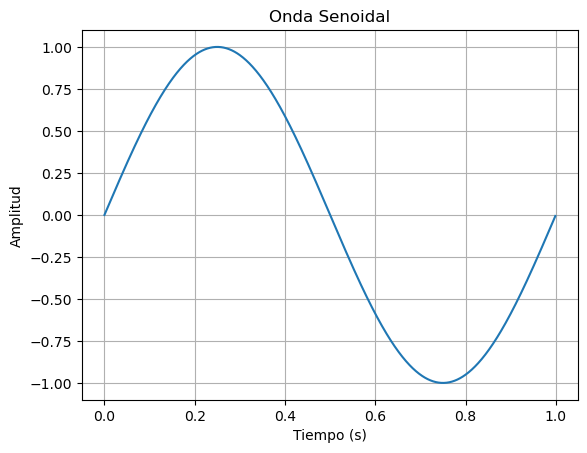

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#Defino los parámetros que quiero que tenga mi señal
vmax= 1
dc=0
ff=1
ph=0
nn= 1000
fs= 1000
ts= 1/fs

#Defino mi función
def mi_funcion_sen ( vmax , dc , ff , ph, nn , fs):
    tt = np.linspace(0, (nn-1)*ts, nn)
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

#Llamo a mi función con los parámetros elegidos arriba
tt, xx = mi_funcion_sen( vmax , dc , ff , ph, nn , fs)

#Grafico la señal obtenida
plt.plot(tt, xx)
plt.title("Onda Senoidal")
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud")
plt.grid(True)
plt.show()

### Bonus

Ya habiendo terminado de diseñar la señal, experimentaremos distintos valores de nuestros parámetros e interpretaremos los resultados obtenidos.

Valores utilizados para los cuatro experimentos:
- fs = 1000 Hz
- N = 1000 muestras

**Experimento 1: ff = 500 Hz**

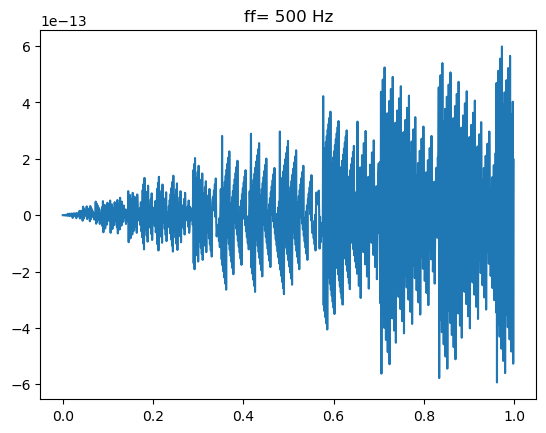

In [8]:
ff = 500
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.figure()
plt.title( 'ff= 500 Hz')
plt.plot(tt, xx)

**Experimento 2: ff = 999 Hz**

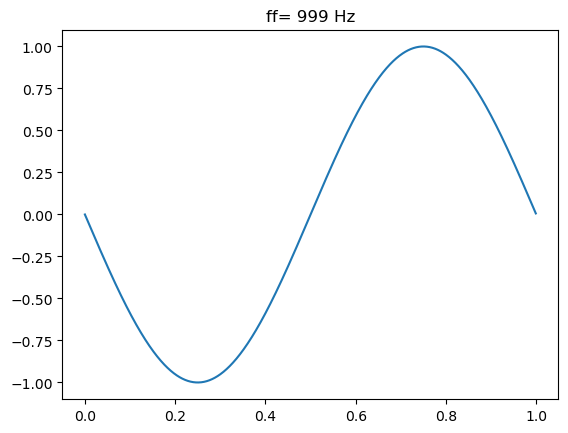

In [10]:
ff = 999
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.figure()
plt.title( 'ff= 999 Hz')
plt.plot(tt, xx)

**Experimento 3: ff = 1001 Hz**

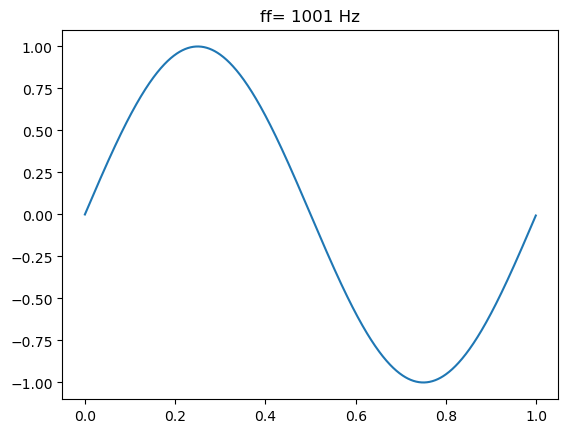

In [11]:
ff = 1001
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.figure()
plt.title( 'ff= 1001 Hz')
plt.plot(tt, xx)

**Experimento 4: ff = 2001 Hz**

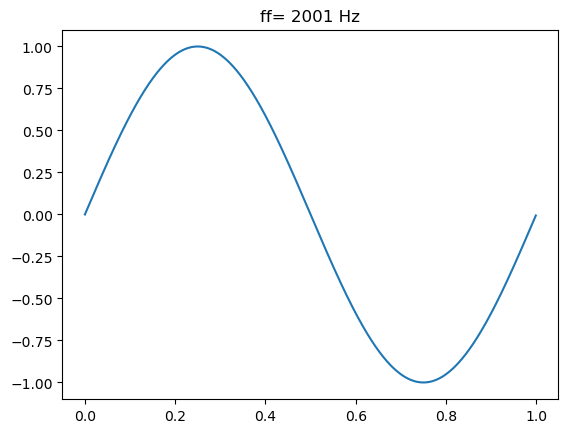

In [12]:
ff = 2001
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)
plt.figure()
plt.title( 'ff= 2001 Hz')
plt.plot(tt, xx)

***Interpretación***

**Primer caso:**

Podemos observar que a pesar de que en primera instancia la señal pareciera algo caótica, esta es casi cero en todo momento (siendo el maximo ~6 * e**-13.

*¿A qué se debe esto?*
Al haber elegido como frecuencia de muestreo (fs) 1000 Hz y como frecuencia de la señal 500 Hz, llegamos al caso límite de nyquist (ff = fs/2). 
Esto implica que por cada período se están tomando unicamente dos muestras. Al ser la fase 0, estas toman los datos en pi y 2*pi iguales a 0.

*¿Pero entonces, por qué el gráfico no muestra 0?*
Aunque teóricamente el número sí es cero, una computadora al no trabajar con el número pi (número infinito) sino con una aproximación de este, el resultado obtenido es muy cercano a cero pero no igual a este.

**Segundo, tercer y cuarto caso:**

En el segundo caso, podemos ver que la señal obtenida se ve exactamente igual a la obtenida anteriormente (en ff=1) pero invertida.
En el tercer y cuarto caso, vemos que la se ve exactamente igual a la obtenida anteriormente (en ff=1).

*¿Por qué es así?* 
Esto se debe a un fenómeno llamado Aliasing. Este fenómeno ocurre cuando superamos nayquist y lo que ocurre es que la señal se ve como una de frecuencia más baja. En el segundo caso tenemos una frecuencia de la señal de 999 Hz, 1000 Hz de frecuencia de muestreo (casi igual a la frecuencia de la señal) y 1000 muestras tomadas, por lo que la señal está submuestreada.

*¿Qué implica esto?* 
Cada período ocurre mucho más rápido que las muestras que se están tomando, por lo que se pierde mucha información de lo que ocurre y la señal termina **pareciendose** a otra (importate, se parecen pero NO son las mismas).

***Conclusión***

Teniendo estos cuatro ejemplos en los que se supera a nayquist, podemos entender el comportamiento que se verá en una señal dependiendo de la cantidad de muestras, la frecuencia del muestreo y, por supuesto, la frecuencia de la señal. Pudiendo dos señales distintas verse como iguales debido a la relación entre ff y fs, además de espejadas y nulas. Esto hace entender que es importante entender los parametros que se están usando al momento de generar la señal para evitar resultados incorrectos.